# INVERTER CIRCUIT 32nm bulk CMOS

> Path: Electrical-Behaviour-Prediction/CMOS/32nm/NOT/Models/simu0/Advanced_Algorithms.ipynb

> https://github.com/GabriellJacinto/Electrical-Behaviour-Prediction/tree/main/CMOS

## Obs

I'm using simu_0/treated_data dataset in this analysis

Joined_data.csv: contém os resultados brutos das simulações elétricas feitas no hspice (Monte Carlo).

Treated_data.csv: contém widths, tensões e temperaturas mapeadas.

O notebook advanced_algotithms usa o joined_data e depois gera o treated_data;

No entanto, ainda não descobri a diferença entre simulação0 e simulação1. Estou usando a simul0

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
path = "../data/raw/CMOS/32nm/NOT/simu_0/treated_data.txt"
plots_dir = "../figures/32nm_cmos/01_data_exploration/"

df = pd.read_csv(path, index_col=0)

Renaming the column 'tensao' to 'voltage' to maintain the English standard

In [3]:
df = df.rename(columns={'tensao' : 'voltage', 'pmos@varp': 'pmos@var'})

## Dataset

Inputs (7 total)
x = [nmos@var, pmos@var, temper, voltage, width_nmos, width_pmos, length]

Outputs (3 total)
y = [tphl, tplh, iint]

Variables (10 total)

- **nmos@var**: variação de processo do transistor NMOS
- **pmos@var**: variação de processo do transistor PMOS
- **tphl**:	tempo de propagação da saída High -> Low
- **tplh**: tempo de propagação da saída Low -> High
- **iint**:	energia dissipada pelo circuito
- **temper**:	temperatura de operação do circuito
- **voltage**: tensão de alimentação (vdd)
- **width_pmos**:	largura W do transistor PMOS
- **width_nmos**: largura W do transistor NMOS
- **length_n&p**: comprimento do canal L dos transistores NMOS e PMOS

Units
- **nmos@var**: Volts (V)
- **pmos@var**: Volts (V)
- **tphl**:	Seconds (s)
- **tplh**: Seconds (s)
- **iint**:	Amperes (A)
- **temper**: Celsius (°C)
- **voltage**: Volts (V)
- **width_pmos**: Meters (m)
- **width_nmos**: Meters (m)
- **length_n&p**: Meters (m)

**Checking if there're null values, how many different values in each variable and type**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155077 entries, 0 to 167999
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   nmos@var    155077 non-null  float64
 1   pmos@var    155077 non-null  float64
 2   tphl        155077 non-null  float64
 3   tplh        155077 non-null  float64
 4   iint        155077 non-null  float64
 5   temper      155077 non-null  float64
 6   voltage     155077 non-null  float64
 7   width_pmos  155077 non-null  float64
 8   width_nmos  155077 non-null  float64
 9   length_n&p  155077 non-null  float64
dtypes: float64(10)
memory usage: 13.0 MB


There're only numerical variables.

In [5]:
df.index

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       167990, 167991, 167992, 167993, 167994, 167995, 167996, 167997, 167998,
       167999],
      dtype='int64', length=155077)

The difference between the length (155.077) and the range of indexes values (0 - 167.999) means treated_data really has been treated. There're gaps that have been taken out of the dataset.

In [6]:
df.size

1550770

155077 x 10 = 1550770 
Total number of data points in the entire table (rows x columns).

In [7]:
df.shape

(155077, 10)

Total of samples/observations: 155.077 (rows)
Total of features/attributes (Xs and Ys): 10 (columns)

In [8]:
df.nunique()

nmos@var        513
pmos@var        489
tphl           8200
tplh          10430
iint          14040
temper            6
voltage           4
width_pmos        5
width_nmos        2
length_n&p        3
dtype: int64

There aren't fixed variables values.

- **nmos@var**: Existem 513 valores diferentes
- **pmos@var**:	Existem 489 valores diferentes
- **tphl**:	Existem 8200 valores diferentes
- **tplh**:	Existem 10430 valores diferentes
- **iint**:	Existem 14040 valores diferentes
- **temper**:	Existem 6 temperaturas diferentes
- **voltage**:	Existem 4 tensões diferentes
- **width_pmos**:	Existem 5 larguras diferentes
- **width_nmos**:	Existem 2 larguras diferentes
- **length_n&p**: Existem 3 valores diferentes

In [9]:
df.describe(include="all")

,nmos@var,pmos@var,tphl,tplh,iint,temper,voltage,width_pmos,width_nmos,length_n&p
count,155077.000000,155077.000000,1.550770e+05,1.550770e+05,1.550770e+05,155077.000000,155077.000000,1.550770e+05,1.550770e+05,1.550770e+05
mean,0.509108,-0.450684,6.592126e-11,-6.440956e-10,-2.063419e-03,37.467033,0.750069,2.266666e-07,8.083333e-08,3.238095e-08
std,0.016825,0.015274,7.263116e-10,2.477490e-09,2.024013e-01,42.982289,0.111693,1.234463e-07,2.531751e-08,4.477225e-09
min,0.461300,-0.493300,-3.819000e-12,-1.000000e-08,-3.342370e+01,-25.000000,0.600000,7.000000e-08,7.000000e-08,2.000000e-08
25%,0.497800,-0.461900,9.825000e-12,7.604000e-12,-2.351000e-15,0.000000,0.700000,1.400000e-07,7.000000e-08,3.200000e-08
50%,0.509000,-0.450500,1.226000e-11,1.080000e-11,-1.657000e-15,50.000000,0.800000,1.400000e-07,7.000000e-08,3.200000e-08
75%,0.520200,-0.440300,1.476000e-11,1.874000e-11,-1.336000e-15,75.000000,0.800000,3.500000e-07,7.000000e-08,3.200000e-08
max,0.586100,-0.405800,1.018000e-08,2.631000e-10,2.933300e+01,100.000000,0.900000,4.200000e-07,1.400000e-07,4.000000e-08


count: number of non-null values (155.077)
mean: average value
std: stadard deviation (how spread out the data is)
min/max: range
25%, 50%, 75%: percentiles, where 50% is median

In [10]:
df.isnull().sum()

nmos@var      0
pmos@var      0
tphl          0
tplh          0
iint          0
temper        0
voltage       0
width_pmos    0
width_nmos    0
length_n&p    0
dtype: int64

As we've seen before, there is no null values.

The dataset is composed only of quantitative (numerical) variables, there's none categorical (non-numerical) variables

In [11]:
df.value_counts()

nmos@var  pmos@var  tphl          tplh          iint           temper  voltage  width_pmos    width_nmos    length_n&p  
0.5097    -0.4458   1.370000e-11  7.213000e-12  -2.729000e-15   50.0   0.6      3.500000e-07  7.000000e-08  3.200000e-08    2
                                                                       0.9      3.500000e-07  7.000000e-08  3.200000e-08    2
                    1.772000e-11  1.276000e-11  -1.376000e-15   50.0   0.7      2.800000e-07  7.000000e-08  3.200000e-08    2
                    1.378000e-11  5.920000e-12  -1.338000e-15  -25.0   0.8      3.500000e-07  7.000000e-08  3.200000e-08    2
                    1.789000e-11  9.758000e-12  -1.329000e-15   25.0   0.7      3.500000e-07  7.000000e-08  3.200000e-08    2
                                                                                                                           ..
0.5020    -0.4467   1.141000e-11  6.283000e-12  -1.865000e-15   0.0    0.9      2.800000e-07  7.000000e-08  3.200000e-08   

#### Frequency of each item

In [12]:
df['nmos@var'].value_counts()

nmos@var
0.5051    1100
0.5096    1084
0.5077    1083
0.5141     932
0.5090     922
          ... 
0.4796     150
0.5215     150
0.4794     150
0.4692     150
0.5861     147
Name: count, Length: 513, dtype: int64

In [13]:
df['pmos@var'].value_counts()

pmos@var
-0.4625    1393
-0.4538    1244
-0.4481    1234
-0.4523    1081
-0.4506     931
           ... 
-0.4756     150
-0.4674     150
-0.4697     150
-0.4917     150
-0.4863     147
Name: count, Length: 489, dtype: int64

In [14]:
df['tphl'].value_counts()

tphl
1.001000e-08    682
1.242000e-11    211
1.168000e-11    210
1.006000e-11    207
1.197000e-11    203
               ... 
3.391000e-12      1
3.236000e-12      1
9.291000e-13      1
9.326000e-13      1
7.690000e-11      1
Name: count, Length: 8200, dtype: int64

In [15]:
df['tplh'].value_counts()

tplh
-9.988000e-09    628
-9.987000e-09    523
-9.995000e-09    452
-9.989000e-09    350
-9.977000e-09    347
                ... 
 4.822000e-11      1
 4.302000e-11      1
 4.203000e-11      1
 5.074000e-11      1
 4.638000e-11      1
Name: count, Length: 10430, dtype: int64

In [16]:
df['iint'].value_counts()

iint
-1.556000e-15    246
-1.553000e-15    239
-1.551000e-15    237
-1.604000e-15    237
-1.550000e-15    234
                ... 
-2.677000e-06      1
 6.004000e-04      1
 2.645000e-05      1
 4.695000e-06      1
-2.217000e-06      1
Name: count, Length: 14040, dtype: int64

In [17]:
df['temper'].value_counts()

temper
 75.0     26761
-25.0     26533
 100.0    25896
 0.0      25767
 25.0     25163
 50.0     24957
Name: count, dtype: int64

In [18]:
df['width_pmos'].value_counts()

width_pmos
1.400000e-07    59077
7.000000e-08    24000
2.800000e-07    24000
3.500000e-07    24000
4.200000e-07    24000
Name: count, dtype: int64

In [19]:
df['width_nmos'].value_counts()

width_nmos
7.000000e-08    131077
1.400000e-07     24000
Name: count, dtype: int64

In [20]:
df['length_n&p'].value_counts()

length_n&p
3.200000e-08    120000
4.000000e-08     24000
2.000000e-08     11077
Name: count, dtype: int64

## Removing outliers

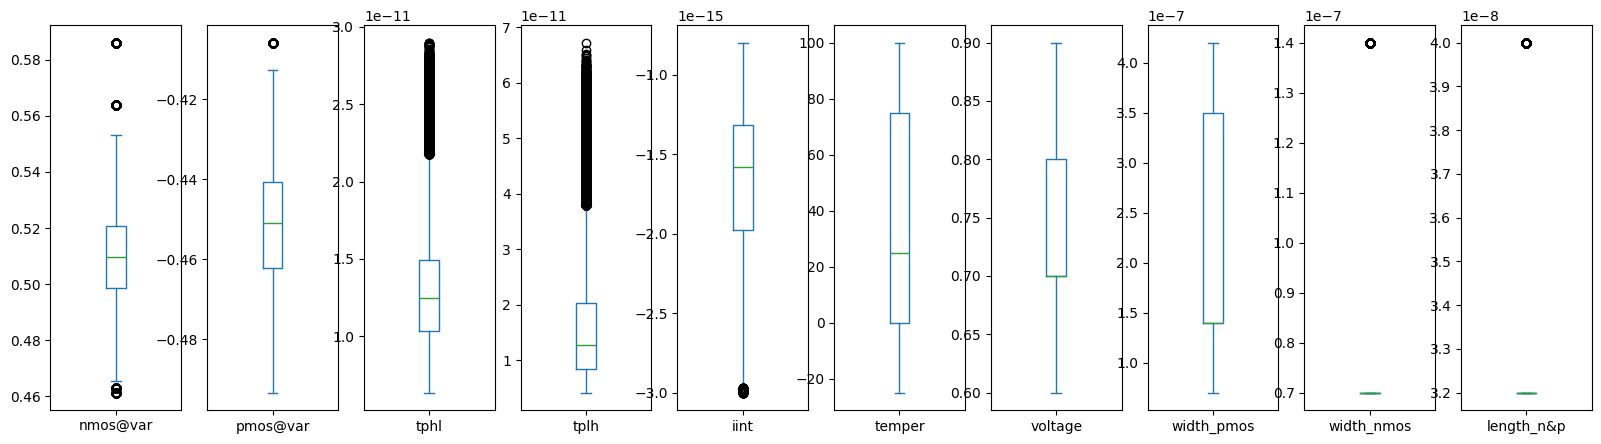

<Figure size 640x480 with 0 Axes>

In [21]:
# Gabriel's code fot removing outliers
df = df[(2e-12<=df.tphl)&(df.tphl<=2.9e-11)]
df = df[(1e-12<=df.tplh)&(df.tplh<=6.8e-11)]
df = df[(-3e-15<=df.iint)]

df.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 15))
plt.figure()
plt.show()
plt.close()

In [22]:
df.describe()

,nmos@var,pmos@var,tphl,tplh,iint,temper,voltage,width_pmos,width_nmos,length_n&p
count,127771.000000,127771.000000,1.277710e+05,1.277710e+05,1.277710e+05,127771.000000,127771.000000,1.277710e+05,1.277710e+05,1.277710e+05
mean,0.509723,-0.451149,1.291333e-11,1.577203e-11,-1.685973e-15,32.301735,0.749356,2.164066e-07,7.819810e-08,3.349893e-08
std,0.016645,0.015210,3.385645e-12,9.954472e-12,4.944592e-16,41.687904,0.107559,1.204728e-07,2.250916e-08,3.121656e-09
min,0.461300,-0.493300,6.351000e-12,4.125000e-12,-3.000000e-15,-25.000000,0.600000,7.000000e-08,7.000000e-08,3.200000e-08
25%,0.498500,-0.462200,1.036000e-11,8.464000e-12,-1.979000e-15,0.000000,0.700000,1.400000e-07,7.000000e-08,3.200000e-08
50%,0.509500,-0.450900,1.248000e-11,1.277000e-11,-1.579000e-15,25.000000,0.700000,1.400000e-07,7.000000e-08,3.200000e-08
75%,0.520700,-0.440600,1.492000e-11,2.024000e-11,-1.317000e-15,75.000000,0.800000,3.500000e-07,7.000000e-08,3.200000e-08
max,0.586100,-0.405800,2.898000e-11,6.720000e-11,-7.993000e-16,100.000000,0.900000,4.200000e-07,1.400000e-07,4.000000e-08


## Exploratory Data Plots

In [23]:
# Correlation
ax = sns.heatmap(df.corr(numeric_only=True), annot=True, cmap=sns.cubehelix_palette(as_cmap=True))
ax.set_title('Correlation between all variables in the dataset')
ax=ax
plt.savefig(f"{plots_dir}/correlation.png")
plt.close()

In [24]:
df.corr()

,nmos@var,pmos@var,tphl,tplh,iint,temper,voltage,width_pmos,width_nmos,length_n&p
nmos@var,1.000000,0.034806,0.174995,-0.022641,0.112036,0.038418,0.002917,0.034796,0.032598,-0.022720
pmos@var,0.034806,1.000000,0.014604,-0.070825,-0.053504,-0.023705,-0.001645,-0.031196,-0.019272,0.014684
tphl,0.174995,0.014604,1.000000,0.238986,0.209867,0.461049,-0.112415,0.028063,-0.410514,0.232621
tplh,-0.022641,-0.070825,0.238986,1.000000,0.264389,0.520156,-0.055632,-0.696719,-0.288699,0.123447
iint,0.112036,-0.053504,0.209867,0.264389,1.000000,-0.422117,-0.076660,-0.434837,-0.300066,0.201189
temper,0.038418,-0.023705,0.461049,0.520156,-0.422117,1.000000,-0.007740,-0.139460,-0.130118,0.058240
voltage,0.002917,-0.001645,-0.112415,-0.055632,-0.076660,-0.007740,1.000000,-0.010176,-0.015177,0.003433
width_pmos,0.034796,-0.031196,0.028063,-0.696719,-0.434837,-0.139460,-0.010176,1.000000,0.615506,-0.304539
width_nmos,0.032598,-0.019272,-0.410514,-0.288699,-0.300066,-0.130118,-0.015177,0.615506,1.000000,-0.174886
length_n&p,-0.022720,0.014684,0.232621,0.123447,0.201189,0.058240,0.003433,-0.304539,-0.174886,1.000000


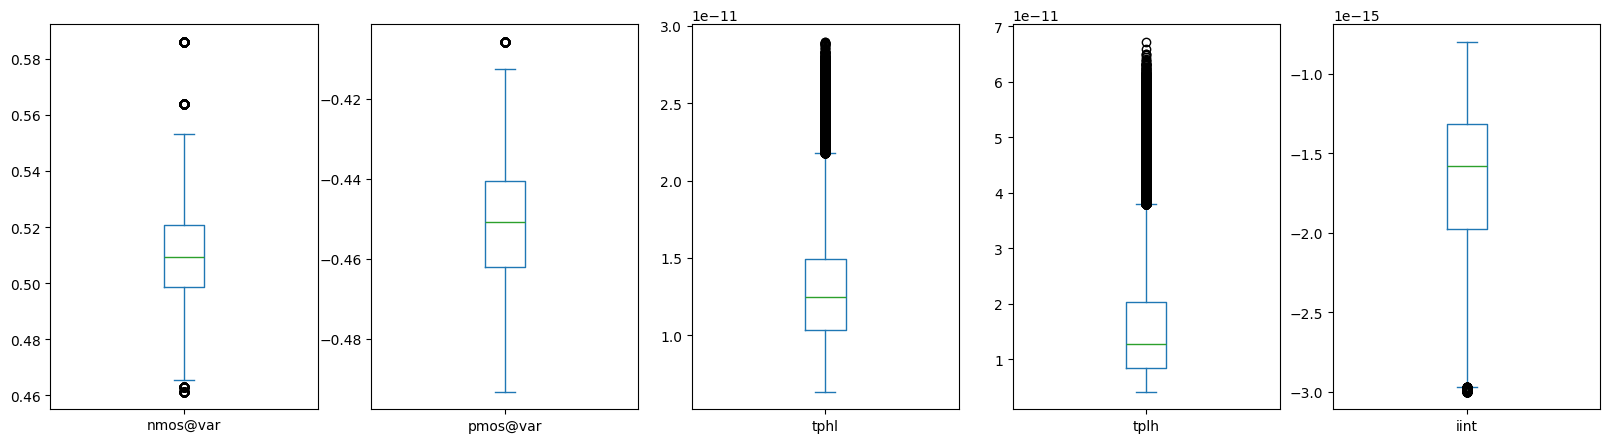

In [25]:
variables = ['temper', 'voltage', 'width_pmos', 'width_nmos']
cols = [c for c in df.columns if 'length' not in c.lower() and c not in variables]
axes = df[cols].plot(kind='box', figsize=(20,5), subplots=True, layout=(1, len(cols)))

plt.savefig(f"{plots_dir}/boxplot.png")
plt.show()
plt.close()

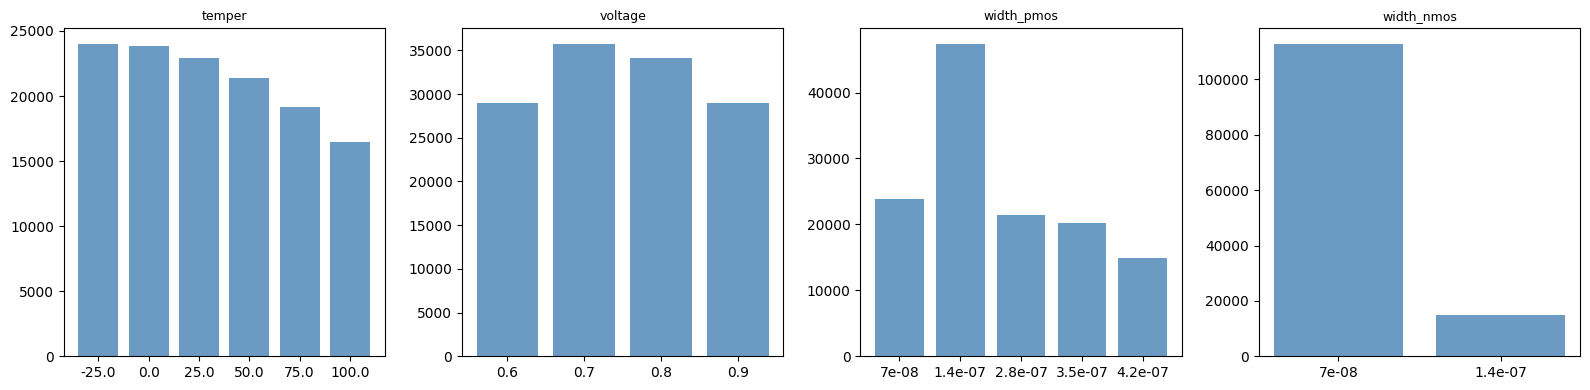

In [26]:
cols = ['temper', 'voltage', 'width_pmos', 'width_nmos']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color='steelblue', alpha=0.8)
    axes[i].set_title(col, fontsize=9)

plt.tight_layout()
plt.savefig(f"{plots_dir}/count_plot.png")
plt.show()
plt.close()

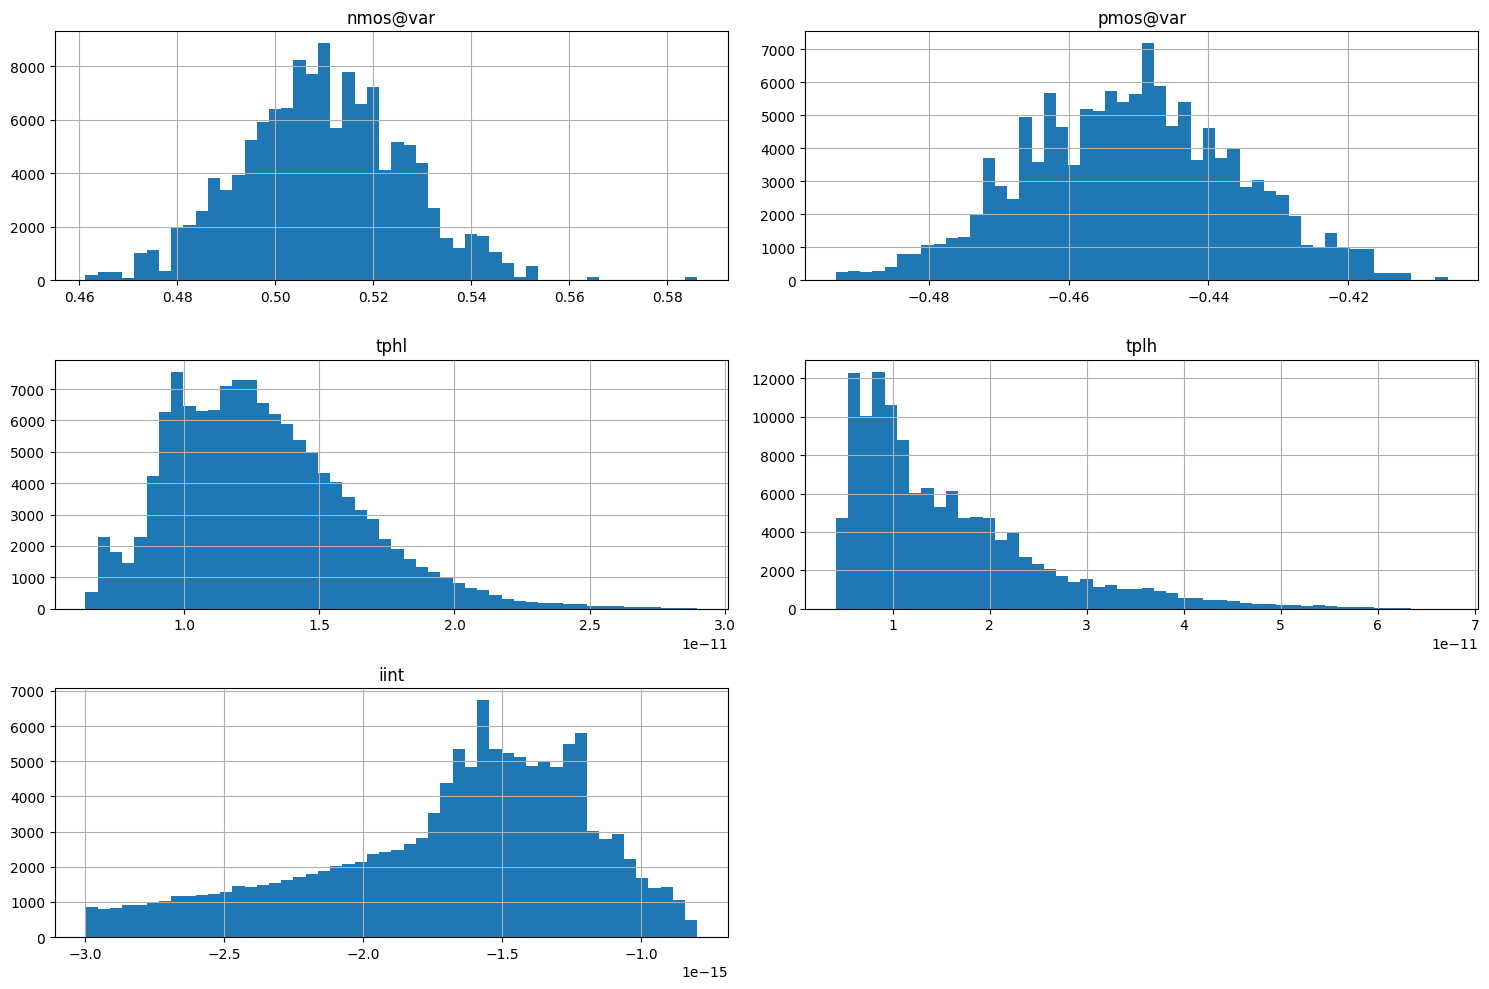

In [27]:
df[['nmos@var', 'pmos@var', 'tphl', 'tplh', 'iint']].hist(
    bins=50, 
    figsize=(15, 10), 
    layout=(3, 2)
)
plt.tight_layout()
plt.savefig(f"{plots_dir}/histogram.png")
plt.show()
plt.close()

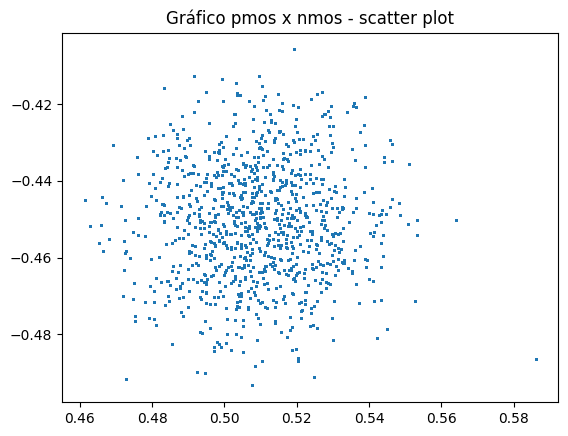

In [28]:
plt.plot('nmos@var', 'pmos@var', data=df, linestyle='none', marker='D', markersize=1)
plt.title('Gráfico pmos x nmos - scatter plot')
plt.savefig(f"{plots_dir}/scatter_plot.png")
plt.show()
plt.close()

## Train, Validation, Test Sets & Scaling (StandardScaler)

First split: 75% training, 25% test
Secound split (train, validation):
33% of 75% ~ 25% of the original data becomes the validation set

Result:
- Train ~50%
- Validation ~25%
- Test 25%

In [29]:
X = df.drop(columns=['tphl', 'tplh', 'iint'])
y = df[['tphl', 'tplh', 'iint']]
print(X.shape)
print(y.shape)

(127771, 7)
(127771, 3)


In [30]:
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

set_config(transform_output="pandas")

seed = 23

# Test set 25%
Xtr, Xte, ytr, yte = train_test_split(X, y, random_state=seed, test_size=0.25)

# Train/Validation set - train total ~50% and validation ~25%
X_train, X_val, y_train, y_val = train_test_split(Xtr, ytr, random_state=seed, test_size=0.33)

# The model only knows the train data (fit() only on training data, never on test/validation)
scaler_x = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train)

X_train_sc = scaler_x.transform(X_train)
X_val_sc = scaler_x.transform(X_val)
Xte_sc = scaler_x.transform(Xte)

y_train_sc = scaler_y.transform(y_train)
y_val_sc = scaler_y.transform(y_val)
yte_sc = scaler_y.transform(yte)

print("Train set X", X_train_sc.shape)
print("Train set y", y_train_sc.shape)
print("Validation set X", X_val_sc.shape)
print("Validation set y", y_val_sc.shape)
print("Test set X", Xte_sc.shape)
print("Test set y", yte_sc.shape)

Train set X (64204, 7)
Train set y (64204, 3)
Validation set X (31624, 7)
Validation set y (31624, 3)
Test set X (31943, 7)
Test set y (31943, 3)


In [31]:
X_train.head()

,nmos@var,pmos@var,temper,voltage,width_pmos,width_nmos,length_n&p
59943,0.5031,-0.4734,-25.0,0.7,4.200000e-07,1.400000e-07,3.200000e-08
86477,0.5141,-0.4249,75.0,0.8,7.000000e-08,7.000000e-08,3.200000e-08
58699,0.5281,-0.4640,100.0,0.7,3.500000e-07,7.000000e-08,3.200000e-08
84759,0.5118,-0.4730,-25.0,0.8,1.400000e-07,7.000000e-08,3.200000e-08
53902,0.5026,-0.4438,0.0,0.7,3.500000e-07,7.000000e-08,3.200000e-08


In [32]:
X_train_sc.head()

,nmos@var,pmos@var,temper,voltage,width_pmos,width_nmos,length_n&p
59943,-0.395440,-1.466100,-1.377877,-0.461522,1.694973,2.771445,-0.483887
86477,0.266399,1.725939,1.021131,0.470434,-1.214869,-0.360823,-0.483887
58699,1.108739,-0.847437,1.620883,-0.461522,1.113004,-0.360823,-0.483887
84759,0.128014,-1.439774,-1.377877,0.470434,-0.632901,-0.360823,-0.483887
53902,-0.425524,0.482031,-0.778125,-0.461522,1.113004,-0.360823,-0.483887


In [33]:
# Salvando dados separados e scalers
X_train_sc.to_csv('../data/processed/dados_32nm_cmos/X_train_sc.csv', index=False)
X_val_sc.to_csv('../data/processed/dados_32nm_cmos/X_val_sc.csv', index=False)
Xte_sc.to_csv('../data/processed/dados_32nm_cmos/X_test_sc.csv', index=False)

y_train_sc.to_csv('../data/processed/dados_32nm_cmos/y_train_sc.csv', index=False)
y_val_sc.to_csv('../data/processed/dados_32nm_cmos/y_val_sc.csv', index=False)
yte_sc.to_csv('../data/processed/dados_32nm_cmos/y_test_sc.csv', index=False)

import joblib

joblib.dump(scaler_x, '../data/processed/dados_32nm_cmos/scaler_x.pkl')
joblib.dump(scaler_y, '../data/processed/dados_32nm_cmos/scaler_y.pkl')

['../data/processed/dados_32nm_cmos/scaler_y.pkl']

### Sets Visualization


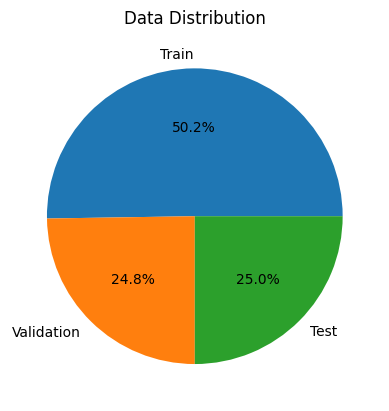

In [34]:
sizes = [len(X_train), len(X_val), len(Xte)]
labels = ['Train', 'Validation', 'Test']

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Data Distribution')
plt.savefig(f"{plots_dir}/data_distribution.png")
plt.show()
plt.close()

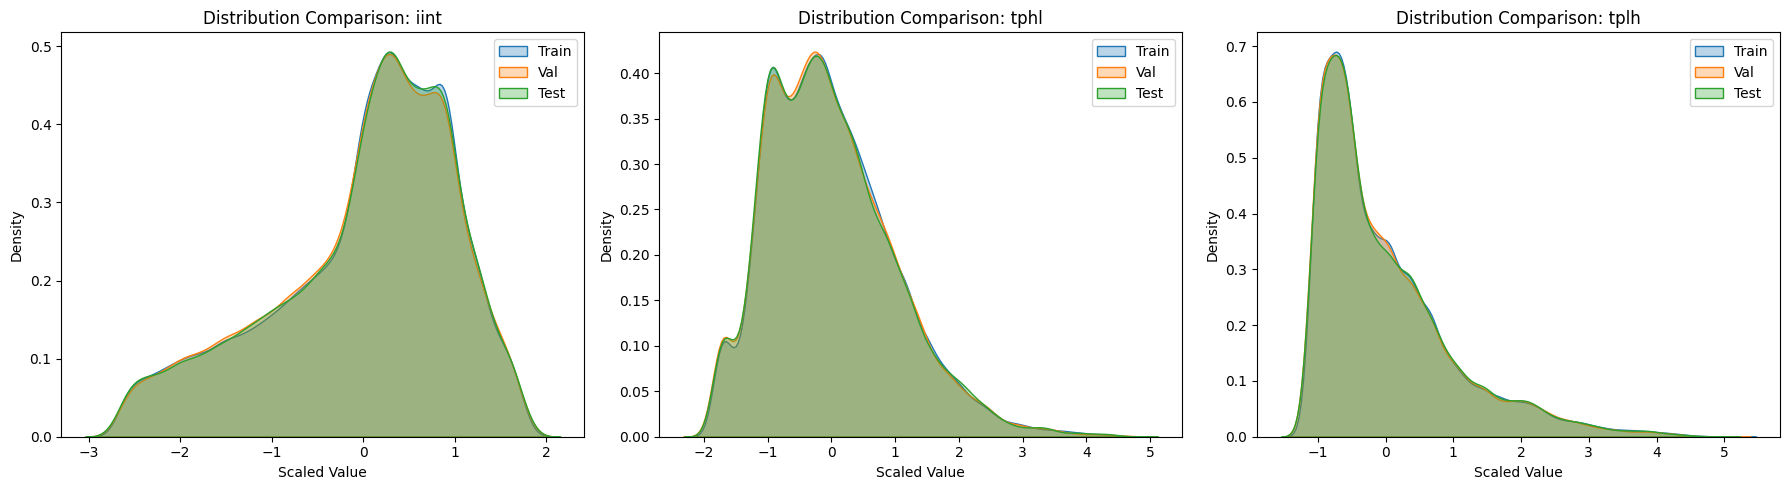

In [35]:
targets = ['iint', 'tphl', 'tplh']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(targets):
    sns.kdeplot(y_train_sc[col], label='Train', ax=axes[i], fill=True, alpha=0.3)
    sns.kdeplot(y_val_sc[col], label='Val', ax=axes[i], fill=True, alpha=0.3)
    sns.kdeplot(yte_sc[col], label='Test', ax=axes[i], fill=True, alpha=0.3)
    
    axes[i].set_title(f'Distribution Comparison: {col}')
    axes[i].set_xlabel('Scaled Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.savefig(f"{plots_dir}/distribution_comparison.png")
plt.show()
plt.close()